# 本次模擬cmd log資訊

* 只保留run.log最後200行的資訊和AMReX finalize(如下)


In [1]:
from datetime import datetime, timedelta
import re

end_time = None
start_time = None
elapsed_hms = None

with open("run.log") as f:
    lines = [line.strip() for line in f if line.strip()]

# 最後一行 = End Time
end_time_str = lines[-1]
end_time = datetime.strptime(end_time_str, "%a %b %d %H:%M:%S %Z %Y")

# 找 Total run time
elapsed_sec = None

for line in lines:
    if line.startswith("Total run time"):
        m = re.search(r'([\d.]+)', line)
        if m:
            elapsed_sec = float(m.group(1))
        break

if elapsed_sec is not None:
    start_time = end_time - timedelta(seconds=elapsed_sec)

    h = int(elapsed_sec // 3600)
    m = int((elapsed_sec % 3600) // 60)
    s = int(elapsed_sec % 60)

    elapsed_hms = f"{h:02d}:{m:02d}:{s:02d}"

print("Simulation Information")
print("----------------------")
print(f"Start Time : {start_time.strftime('%a %b %d %H:%M:%S %Y')}")
print(f"End Time   : {end_time.strftime('%a %b %d %H:%M:%S %Y')}")
print(f"Run Time   : {elapsed_hms}")

Simulation Information
----------------------
Start Time : Mon Jun 29 06:33:35 2026
End Time   : Mon Jun 29 12:15:49 2026
Run Time   : 05:42:13


# 使用者設定

In [2]:
import re
from pathlib import Path

import yt
import numpy as np
import pandas as pd


# =========================
# User settings
# =========================#"/home/gkaiwi58/FAM/FerroX/Exec/MFIM_mod_1/"
PLOT_DIR = Path("./plts")          # plotfile 所在資料夾
PLOT_PREFIX = "plt"
PLOT_INTERVAL = 10000000           # 你的 plot_int，例如 100

# 如果你的 field 名稱不是 ("boxlib", "Phi")，後面會自動列出 field_list 方便你改
PHI_FIELD_CANDIDATES = [
    ("boxlib", "Phi"),
    ("boxlib", "phi"),
    ("boxlib", "PoissonPhi"),
    "Phi",
    "phi",
    "PoissonPhi",
]

wanted = {"alpha", "beta", "gamma", "BigGamma", "g11", "g44", "FE_lo", "FE_hi"}

def parse_value(values):
    vals = [float(v) for v in values.split()]
    return vals[0] if len(vals) == 1 else vals

params = {}

with open("inputs") as f:
    for line in f:
        line = line.strip()
        if not line or "=" not in line:
            continue

        key, values = line.split("=", 1)
        if key.strip() in wanted:
            params[key.strip()] = parse_value(values.strip())

# FE layer range, unit: nm
FE_Z_LO_NM = params["FE_lo"][2] / 1e-9
FE_Z_HI_NM = params["FE_hi"][2] / 1e-9

# 如果你想只畫 FE 的 x 範圍，也可以打開這兩行
# 若是 MFIS 全幅 FE，通常用整個 x 範圍即可

FE_X_LO_NM = params["FE_lo"][0] / 1e-9
FE_X_HI_NM = params["FE_hi"][0] / 1e-9

FE_Y_LO_NM = params["FE_lo"][1] / 1e-9
FE_Y_HI_NM = params["FE_hi"][1] / 1e-9

ALPHA = params["alpha"]
BETA = params["beta"]
SMALL_GAMMA = params["gamma"]
BIG_GAMMA = params["BigGamma"]
G11 = params["g11"]
G44 = params["g44"]
T_FE = 1e-9 * (FE_Z_HI_NM - FE_Z_LO_NM)  # FE layer thickness, unit: m

print("Parameters:")
print(f"  ALPHA = {ALPHA:.3e}")
print(f"  BETA = {BETA:.3e}")
print(f"  SMALL_GAMMA = {SMALL_GAMMA:.3e}")
print(f"  BIG_GAMMA = {BIG_GAMMA:.3e}")
print(f"  G11 = {G11:.3e}")
print(f"  G44 = {G44:.3e}")
print(f"  FE layer thickness = {T_FE:.3e} m")
# 3D sweep plot要畫的電壓欄位：-4.5, -4.0, ..., 4.5
VOLTAGES = np.arange(-4.5, 5.0, 0.5)
# 3D contour 要畫的plotfile


Parameters:
  ALPHA = -6.250e+09
  BETA = 3.500e+10
  SMALL_GAMMA = 1.500e+11
  BIG_GAMMA = 1.000e+02
  G11 = 1.000e-09
  G44 = 1.000e-09
  FE layer thickness = 7.000e-09 m


## Utils

In [3]:
def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v

def read_full_field_from_grids(ds, field):
    """
    Read a cell-centered AMReX field from all yt grids
    and stitch them into one full-domain numpy array.

    Return:
        full: numpy array with shape ds.domain_dimensions
    """
    dims = np.array(ds.domain_dimensions, dtype=int)
    full = np.empty(tuple(dims), dtype=float)

    domain_lo = ds.domain_left_edge.to_value()
    domain_hi = ds.domain_right_edge.to_value()
    dx = (domain_hi - domain_lo) / dims

    for grid in ds.index.grids:
        arr = to_numpy(grid[field])

        left = grid.LeftEdge.to_value()

        # grid start index in global domain
        start = np.rint((left - domain_lo) / dx).astype(int)

        nx, ny, nz = arr.shape
        i0, j0, k0 = start
        i1, j1, k1 = i0 + nx, j0 + ny, k0 + nz

        full[i0:i1, j0:j1, k0:k1] = arr

    return full

def get_step_from_name(name):
    m = re.fullmatch(r"plt(\d+)", str(name))
    return int(m.group(1)) if m else None


def find_plot_names(plot_dir):
    names = []
    for p in plot_dir.iterdir():
        if p.is_dir() and re.fullmatch(r"plt\d+", p.name):
            names.append(p.name)
    names.sort(key=lambda n: get_step_from_name(n))
    return names

In [4]:
from pathlib import Path
import yt


plot_paths = sorted([p for p in PLOT_DIR.glob(f"{PLOT_PREFIX}*") if p.is_dir()])

# 只要名稱 (plt000100, ...)
plot_names = [p.name for p in plot_paths]

print("Available plotfiles:")
for name in plot_names:
    print("  ", name)
    
print(len(plot_names), "plotfiles found in", PLOT_DIR)
PLOTFILE_NAME = plot_names[30] 


Available plotfiles:
   plt00000000
   plt00003729
   plt00004368
   plt00006549
   plt00008796
   plt00009956
   plt00011346
   plt00015512
   plt00017451
   plt00019004
   plt00020968
   plt00021574
   plt00023677
   plt00026857
   plt00028164
   plt00029726
   plt00031861
   plt00032470
   plt00034797
   plt00035286
   plt00035891
   plt00040599
   plt00041486
   plt00042133
   plt00044117
   plt00046245
   plt00047562
   plt00049790
   plt00050384
   plt00050961
   plt00053222
   plt00056183
   plt00057230
   plt00057711
   plt00060536
   plt00061699
   plt00063364
   plt00064468
   plt00065013
   plt00066749
   plt00067678
   plt00068280
   plt00070978
   plt00072516
   plt00073807
   plt00077310
   plt00077825
47 plotfiles found in plts


## 探索yt資料結構

### dir(ds) # 列出 ds 所有(variable和property和method)

* Note: variable和property和method統稱attribute

In [5]:
ds = yt.load(PLOT_DIR/plot_names[0])  # 載入指定的 plotfile
dir(ds) # 列出 ds 所有變數和屬性和方法
#[a for a in dir(ds) if not a.startswith("_")]

yt : [INFO     ] 2026-06-29 13:42:31,884 Parameters: current_time              = 0.0


yt : [INFO     ] 2026-06-29 13:42:31,886 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:31,887 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:31,888 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_add_object_class',
 '_arr',
 '_assign_unit_system',
 '_create_unit_registry',
 '_default_cparam_filename',
 '_determined_fields',
 '_field_info',
 '_field_info_class',
 '_field_list',
 '_find_extremum',
 '_force_periodicity',
 '_get_field_info',
 '_get_field_info_helper',
 '_guess_candidates',
 '_hash',
 '_header_mesh_start',
 '_index_class',
 '_input_filename',
 '_instantiated',
 '_instantiated_index',
 '_ionization_label_format',
 '_is_valid',
 '_is_within_domain',
 '_load_requirements',
 '_localize_ch

### 用key word查看dir(ds)中可能會用到的attribute

In [6]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "domain"
    if "domain" in a.lower():
        print(a)

_is_within_domain
domain_center
domain_dimensions
domain_left_edge
domain_offset
domain_right_edge
domain_width


In [7]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "field"
    if "field" in a.lower():
        print(a)

_determined_fields
_field_info
_field_info_class
_field_list
_get_field_info
_get_field_info_helper
add_deposited_particle_field
add_field
add_gradient_fields
add_mesh_sampling_particle_field
create_field_info
default_field
default_species_fields
derived_field_list
field_info
field_list
field_units
fields
fields_detected
find_field_values_at_point
find_field_values_at_points
particle_fields_by_type
set_field_label_format
setup_deprecated_fields


In [8]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "index"
    if "index" in a.lower():
        print(a)

_index_class
_instantiated_index
index


* **grid相關attribute在index內**

In [9]:
for a in dir(ds.index): # 列出 ds.index 裡有哪些屬性和方法，特別是包含 "index"
    if "grid" in a.lower():
        print(a)

_count_grids
_get_grid_objs
_get_grid_tree
_get_grids
_grid_chunksize
_grids
_initialize_grid_arrays
_populate_grid_objects
grid
grid_corners
grid_dimensions
grid_left_edge
grid_levels
grid_particle_count
grid_right_edge
grid_start_index
grids
lock_grids_to_parents
num_grids
select_grids


In [10]:
for a in dir(ds.index.grids[0]): # 列出 ds.index.grids[0] 裡有哪些屬性和方法，特別是包含 "index"
    
        print(a)

ActiveDimensions
Children
LeftEdge
Level
NumberOfParticles
OverlappingSiblings
Parent
RightEdge
__abstractmethods__
__add__
__and__
__annotations__
__class__
__delattr__
__delitem__
__dict__
__dir__
__doc__
__eq__
__format__
__ge__
__getattribute__
__getitem__
__getstate__
__gt__
__hash__
__init__
__init_subclass__
__int__
__invert__
__le__
__lt__
__module__
__ne__
__new__
__or__
__reduce__
__reduce_ex__
__repr__
__setattr__
__setitem__
__sizeof__
__slots__
__str__
__sub__
__subclasshook__
__weakref__
__xor__
_abc_impl
_activate_cache
_base_offset
_cache_mask
_child_index_mask
_child_indices
_child_mask
_children_ids
_chunk_info
_chunked_read
_compute_extrema
_con_args
_container_fields
_count_particles
_current_chunk
_current_fluid_type
_current_particle_type
_data_source
_debug
_default_field_parameters
_derived_quantity_chunking
_determine_fields
_distributed
_ds_hold
_extrema_cache
_field_cache
_field_lock
_field_parameter_state
_field_type_state
_fill_child_mask
_finalize_parallel

## yt dataset

* 可以從上一個部份"探索yt資料結構"找想用的attribute

In [11]:
print("========== Dataset ==========")
print("type:", type(ds))
print("用SI單位")
print("current_time(s):", ds.current_time)
print("domain_left_edge(m) :", ds.domain_left_edge)
print("domain_right_edge(m):", ds.domain_right_edge)
print("domain_center:", ds.domain_center)
print("domain_width(domain邊長):", ds.domain_width)
print("domain_offset:", ds.domain_offset)
print("domain_dimensions(xyz方向各切成幾格):", ds.domain_dimensions)
print("dimensionality:", ds.dimensionality)
print("geometry:", ds.geometry)
#print("periodicity:", ds.periodicity)

print("\n========== Fields ==========")
for f in ds.field_list:
    print(" ", f)


========== Dataset ==========
type: <class 'yt.frontends.amrex.data_structures.BoxlibDataset'>
用SI單位
current_time(s): 0.0 code_time
domain_left_edge(m) : [-1.6e-08 -1.6e-08  0.0e+00] code_length
domain_right_edge(m): [1.60e-08 1.60e-08 2.85e-08] code_length
domain_center: [0.000e+00 0.000e+00 1.425e-08] code_length
domain_width(domain邊長): [3.20e-08 3.20e-08 2.85e-08] code_length
domain_offset: [0 0 0]
domain_dimensions(xyz方向各切成幾格): [64 64 59]
dimensionality: 3
geometry: cartesian

========== Fields ==========
  ('boxlib', 'Ex')
  ('boxlib', 'Ey')
  ('boxlib', 'Ez')
  ('boxlib', 'Phi')
  ('boxlib', 'PhiDiff')
  ('boxlib', 'PoissonRHS')
  ('boxlib', 'Px')
  ('boxlib', 'Py')
  ('boxlib', 'Pz')
  ('boxlib', 'alpha')
  ('boxlib', 'beta')
  ('boxlib', 'charge')
  ('boxlib', 'electrons')
  ('boxlib', 'epsilon')
  ('boxlib', 'holes')
  ('boxlib', 'mask')
  ('boxlib', 'theta')
  ('boxlib', 'tphase')


* domain切成多個grid分配給mpi rank平行運算，**資料分散在每個grid**

In [12]:
print("\n========== Grids ==========")
print("number of grids:", len(ds.index.grids))
for i, g in enumerate(ds.index.grids):
    print(f"grid {i}:")
    print("  LeftEdge:", g.LeftEdge)
    print("  RightEdge:", g.RightEdge)
    print("  ActiveDimensions:", g.ActiveDimensions)
    print("  Level:", g.Level)
print(ds.index.grid_start_index)


========== Grids ==========
number of grids: 16
grid 0:
  LeftEdge: [-1.6e-08 -1.6e-08  0.0e+00] code_length
  RightEdge: [-8.00e-09 -8.00e-09  2.85e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 1:
  LeftEdge: [-8.0e-09 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 0.00e+00 -8.00e-09  2.85e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 2:
  LeftEdge: [ 0.0e+00 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 8.00e-09 -8.00e-09  2.85e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 3:
  LeftEdge: [ 8.0e-09 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 1.60e-08 -8.00e-09  2.85e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 4:
  LeftEdge: [-1.6e-08 -8.0e-09  0.0e+00] code_length
  RightEdge: [-8.00e-09  0.00e+00  2.85e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 5:
  LeftEdge: [-8.e-09 -8.e-09  0.e+00] code_length
  RightEdge: [0.00e+00 0.00e+00 2.85e-08] code_length
  ActiveDimensions: [16 16 59]
  Level:

# plot

## **2Dfield繪製**

* g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
* x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置

yt : [INFO     ] 2026-06-29 13:42:32,204 Parameters: current_time              = 0.0


yt : [INFO     ] 2026-06-29 13:42:32,205 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:32,206 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:32,208 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


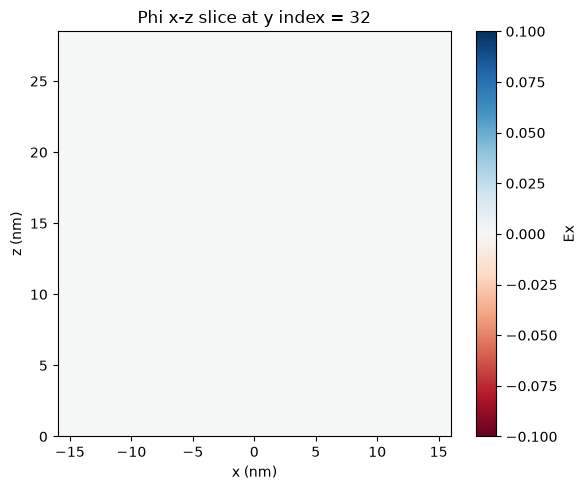

yt : [INFO     ] 2026-06-29 13:42:32,595 Parameters: current_time              = 7.457999999999575e-10


yt : [INFO     ] 2026-06-29 13:42:32,596 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:32,597 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:32,598 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


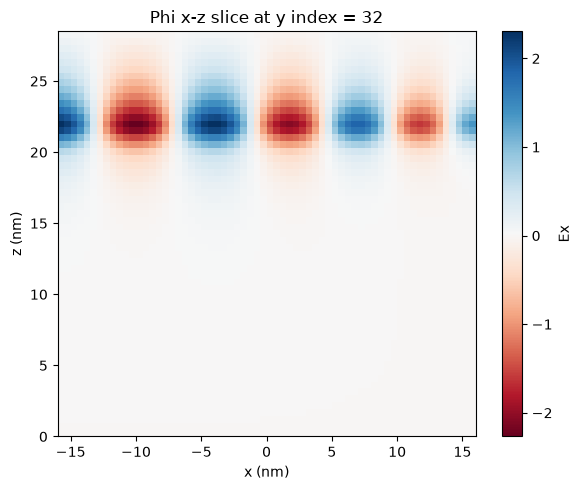

yt : [INFO     ] 2026-06-29 13:42:32,922 Parameters: current_time              = 8.735999999999306e-10


yt : [INFO     ] 2026-06-29 13:42:32,923 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:32,924 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:32,926 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


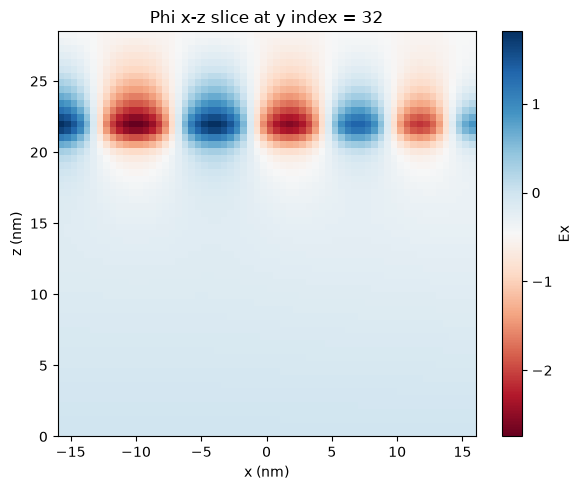

yt : [INFO     ] 2026-06-29 13:42:33,247 Parameters: current_time              = 1.3098000000000345e-09


yt : [INFO     ] 2026-06-29 13:42:33,248 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:33,250 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:33,251 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


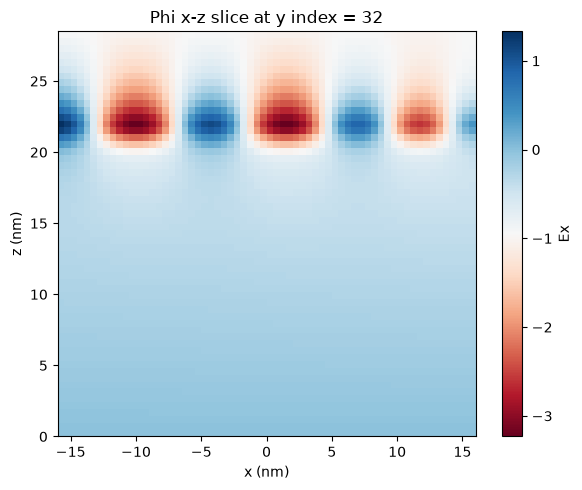

yt : [INFO     ] 2026-06-29 13:42:33,580 Parameters: current_time              = 1.7592000000001723e-09


yt : [INFO     ] 2026-06-29 13:42:33,581 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:33,583 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:33,584 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


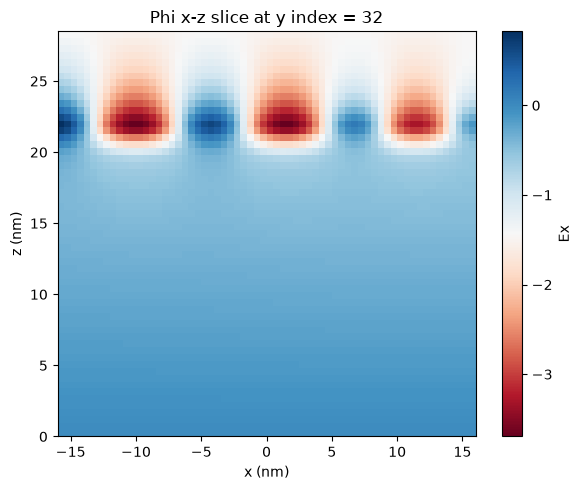

yt : [INFO     ] 2026-06-29 13:42:34,043 Parameters: current_time              = 1.9912000000002435e-09


yt : [INFO     ] 2026-06-29 13:42:34,044 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:34,045 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:34,047 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


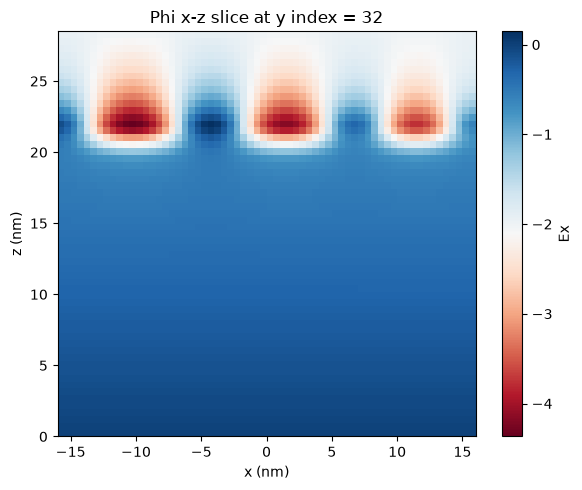

yt : [INFO     ] 2026-06-29 13:42:34,361 Parameters: current_time              = 2.2692000000003288e-09


yt : [INFO     ] 2026-06-29 13:42:34,363 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:34,364 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:34,365 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


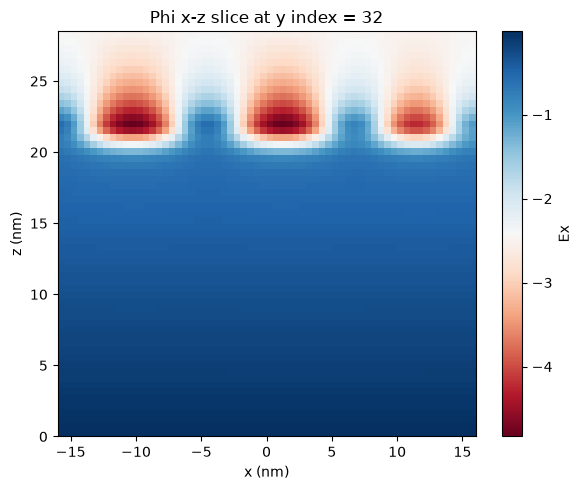

yt : [INFO     ] 2026-06-29 13:42:34,680 Parameters: current_time              = 3.1024000000005844e-09


yt : [INFO     ] 2026-06-29 13:42:34,682 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:34,683 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:34,684 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


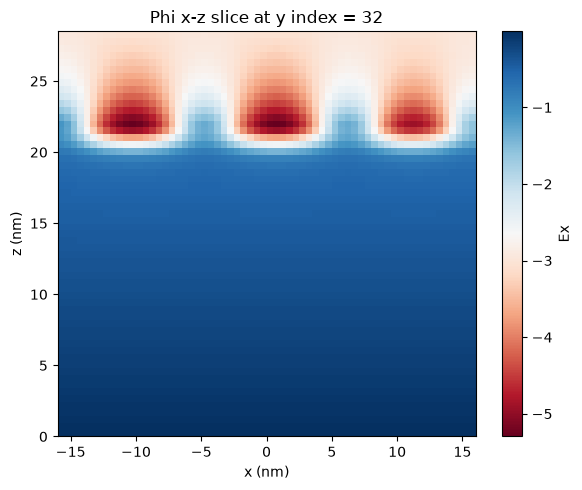

yt : [INFO     ] 2026-06-29 13:42:35,000 Parameters: current_time              = 3.4902000000007033e-09


yt : [INFO     ] 2026-06-29 13:42:35,001 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:35,002 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:35,003 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


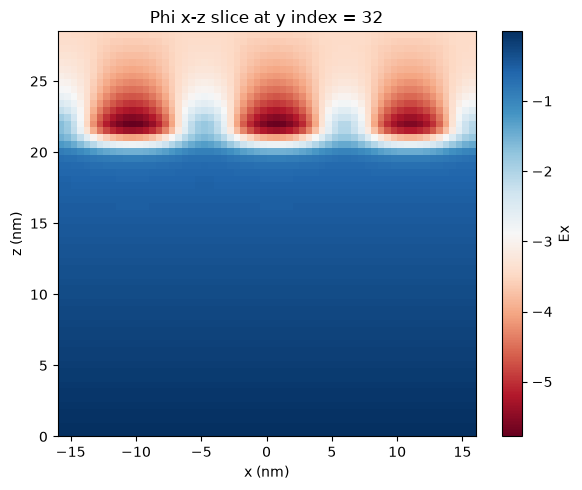

yt : [INFO     ] 2026-06-29 13:42:35,317 Parameters: current_time              = 3.800800000000799e-09


yt : [INFO     ] 2026-06-29 13:42:35,318 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:35,319 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:35,320 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


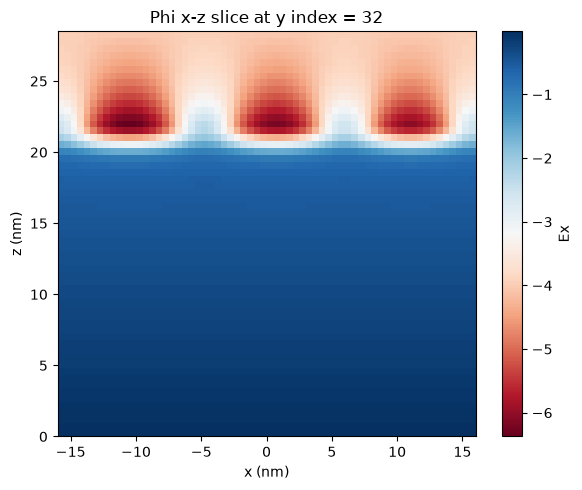

yt : [INFO     ] 2026-06-29 13:42:35,568 Parameters: current_time              = 4.193600000000919e-09


yt : [INFO     ] 2026-06-29 13:42:35,569 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:35,570 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:35,571 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


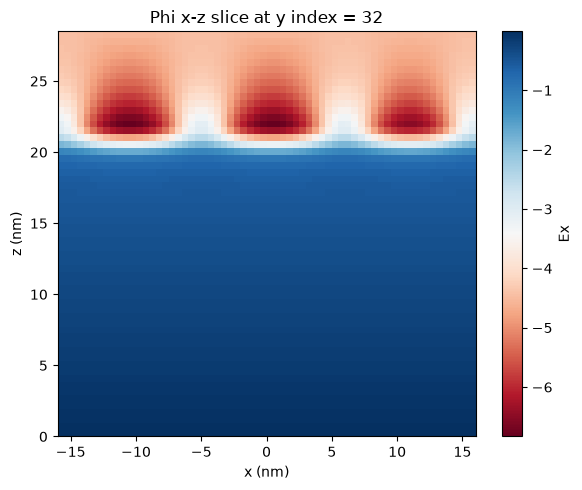

yt : [INFO     ] 2026-06-29 13:42:35,911 Parameters: current_time              = 4.314800000000956e-09


yt : [INFO     ] 2026-06-29 13:42:35,912 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:35,913 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:35,914 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


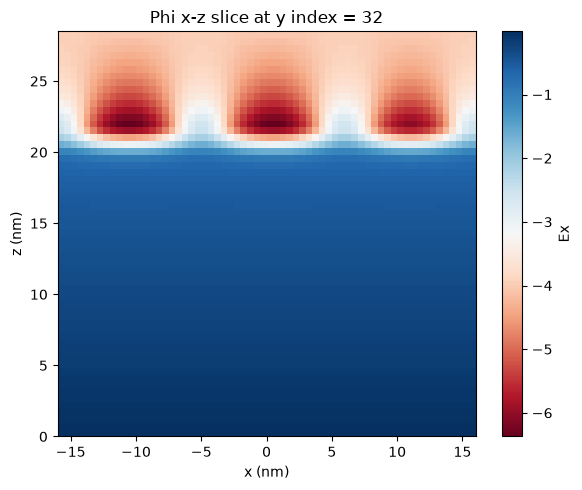

yt : [INFO     ] 2026-06-29 13:42:36,161 Parameters: current_time              = 4.735400000001085e-09


yt : [INFO     ] 2026-06-29 13:42:36,162 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:36,163 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:36,164 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


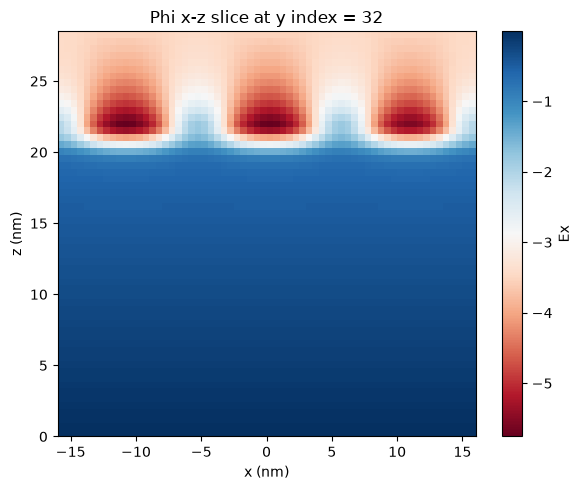

yt : [INFO     ] 2026-06-29 13:42:36,410 Parameters: current_time              = 5.37140000000128e-09


yt : [INFO     ] 2026-06-29 13:42:36,411 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:36,412 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:36,413 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


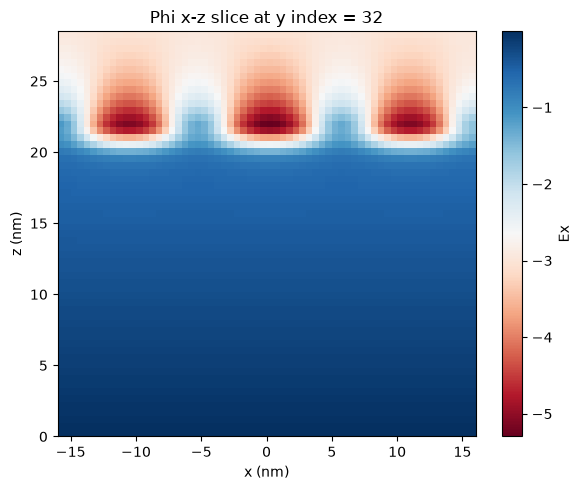

yt : [INFO     ] 2026-06-29 13:42:36,654 Parameters: current_time              = 5.6328000000013605e-09


yt : [INFO     ] 2026-06-29 13:42:36,655 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:36,656 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:36,657 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


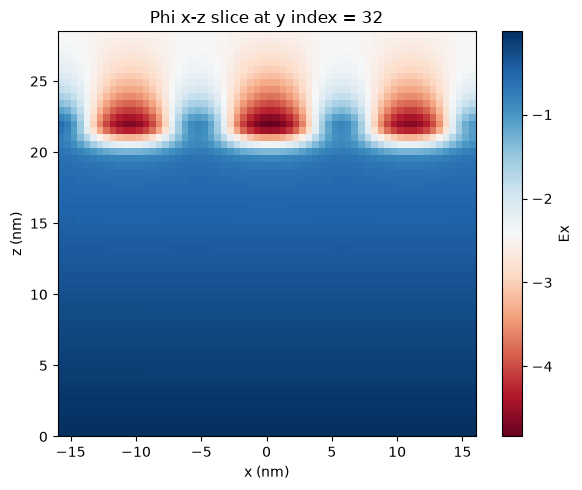

yt : [INFO     ] 2026-06-29 13:42:36,895 Parameters: current_time              = 5.945200000001456e-09


yt : [INFO     ] 2026-06-29 13:42:36,896 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:36,897 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:36,898 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


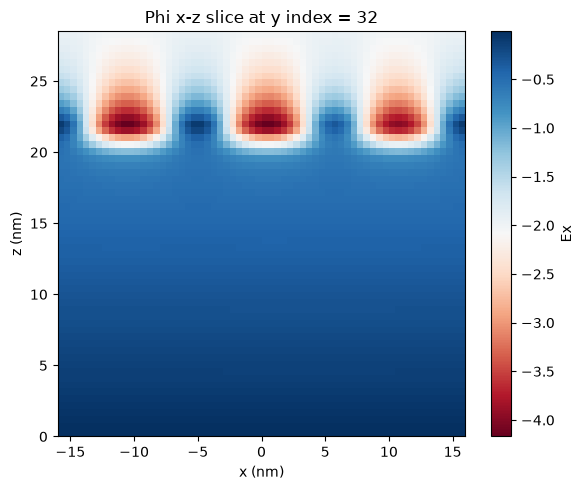

yt : [INFO     ] 2026-06-29 13:42:37,149 Parameters: current_time              = 6.372200000001587e-09


yt : [INFO     ] 2026-06-29 13:42:37,150 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:37,151 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:37,152 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


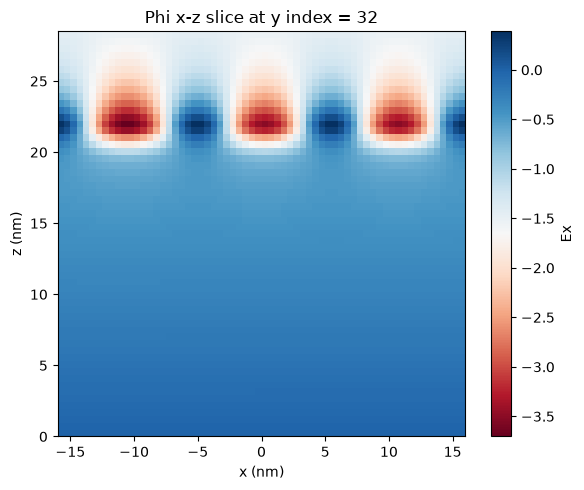

yt : [INFO     ] 2026-06-29 13:42:37,526 Parameters: current_time              = 6.494000000001625e-09


yt : [INFO     ] 2026-06-29 13:42:37,527 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:37,528 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:37,530 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


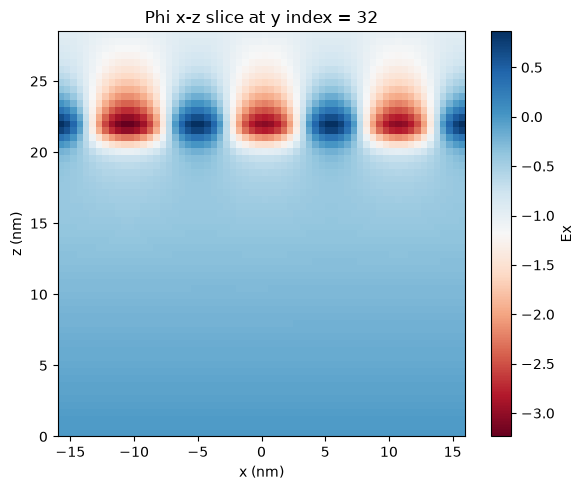

yt : [INFO     ] 2026-06-29 13:42:37,778 Parameters: current_time              = 6.9594000000017675e-09


yt : [INFO     ] 2026-06-29 13:42:37,779 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:37,780 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:37,781 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


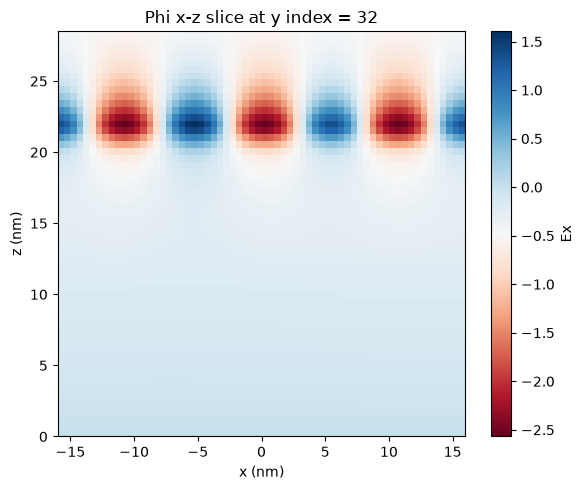

yt : [INFO     ] 2026-06-29 13:42:38,034 Parameters: current_time              = 7.0572000000017975e-09


yt : [INFO     ] 2026-06-29 13:42:38,034 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:38,035 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:38,036 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


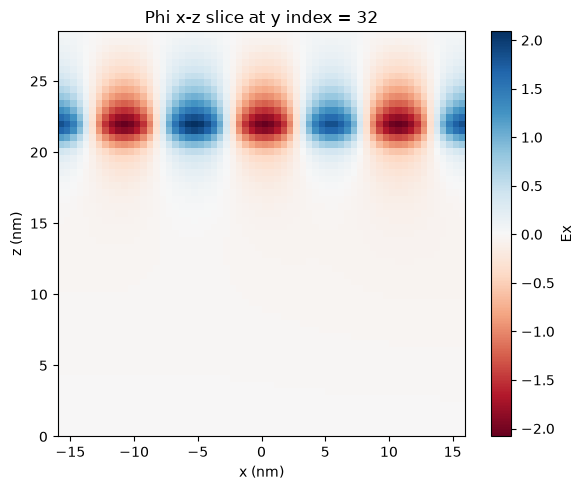

yt : [INFO     ] 2026-06-29 13:42:38,287 Parameters: current_time              = 7.1782000000018346e-09


yt : [INFO     ] 2026-06-29 13:42:38,288 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:38,289 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:38,290 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


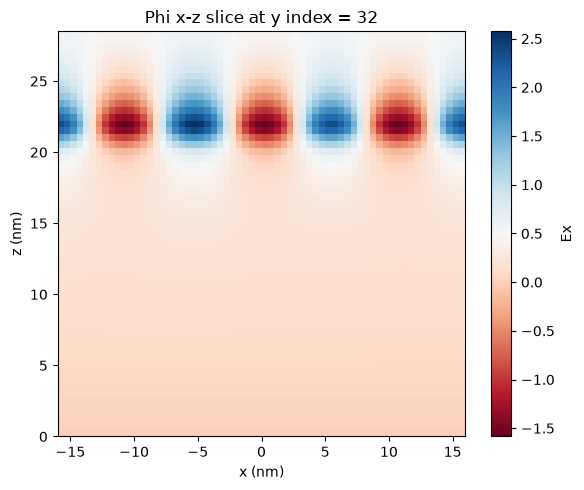

yt : [INFO     ] 2026-06-29 13:42:38,542 Parameters: current_time              = 8.119799999999355e-09


yt : [INFO     ] 2026-06-29 13:42:38,543 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:38,544 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:38,545 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


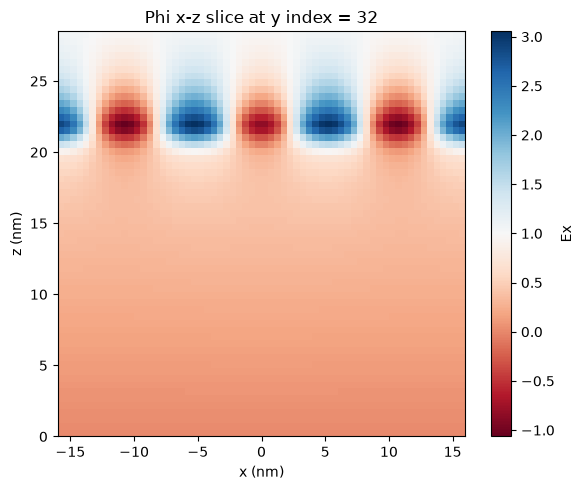

yt : [INFO     ] 2026-06-29 13:42:38,796 Parameters: current_time              = 8.297199999998676e-09


yt : [INFO     ] 2026-06-29 13:42:38,797 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:38,798 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:38,799 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


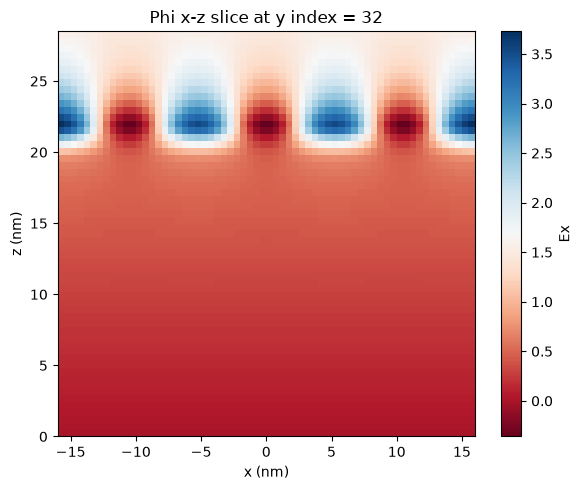

yt : [INFO     ] 2026-06-29 13:42:39,047 Parameters: current_time              = 8.42659999999818e-09


yt : [INFO     ] 2026-06-29 13:42:39,048 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:39,049 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:39,049 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


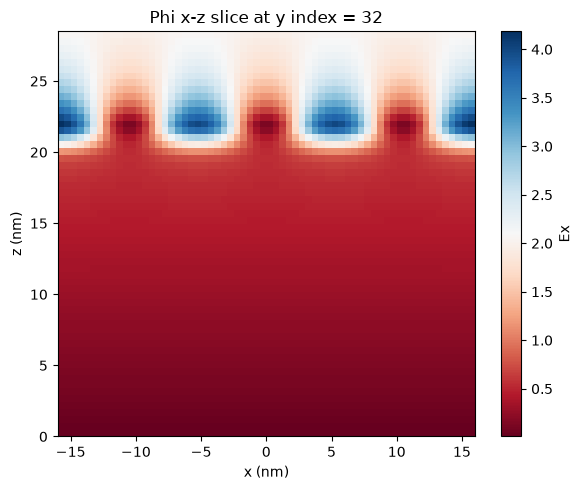

yt : [INFO     ] 2026-06-29 13:42:39,412 Parameters: current_time              = 8.82339999999666e-09


yt : [INFO     ] 2026-06-29 13:42:39,413 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:39,414 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:39,415 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


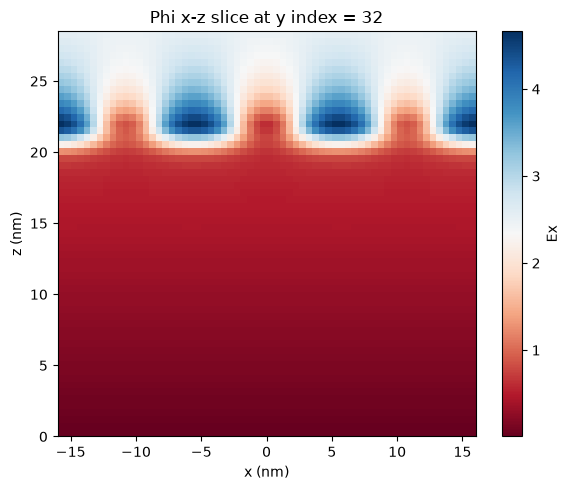

yt : [INFO     ] 2026-06-29 13:42:39,651 Parameters: current_time              = 9.248999999995031e-09


yt : [INFO     ] 2026-06-29 13:42:39,651 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:39,652 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:39,653 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


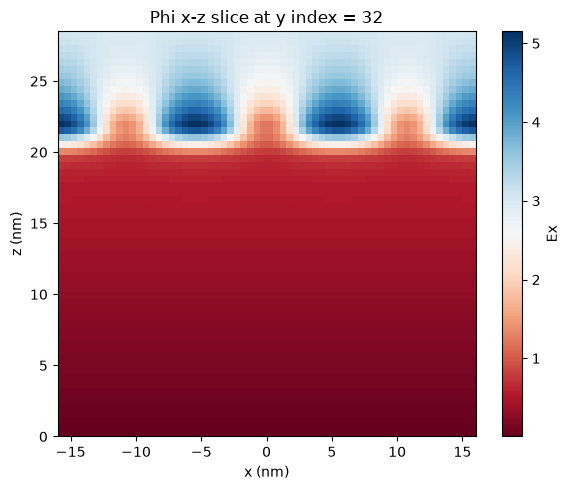

yt : [INFO     ] 2026-06-29 13:42:39,891 Parameters: current_time              = 9.512399999994022e-09


yt : [INFO     ] 2026-06-29 13:42:39,892 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:39,893 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:39,894 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


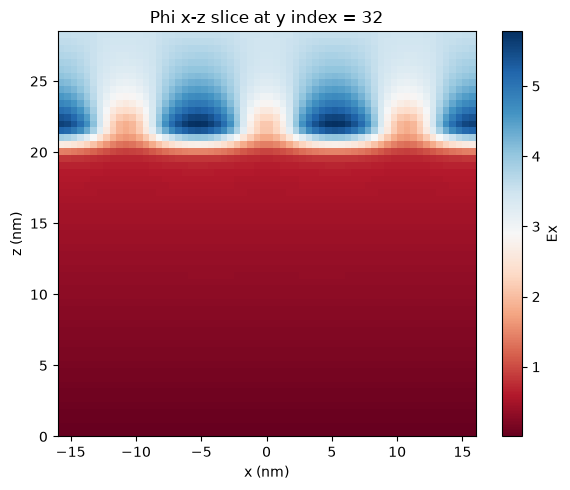

yt : [INFO     ] 2026-06-29 13:42:40,130 Parameters: current_time              = 9.957999999992316e-09


yt : [INFO     ] 2026-06-29 13:42:40,131 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:40,132 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:40,132 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


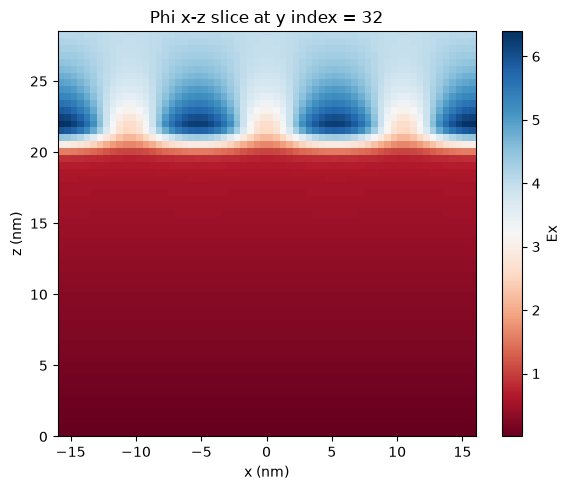

yt : [INFO     ] 2026-06-29 13:42:40,373 Parameters: current_time              = 1.0076799999991861e-08


yt : [INFO     ] 2026-06-29 13:42:40,374 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:40,375 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:40,376 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


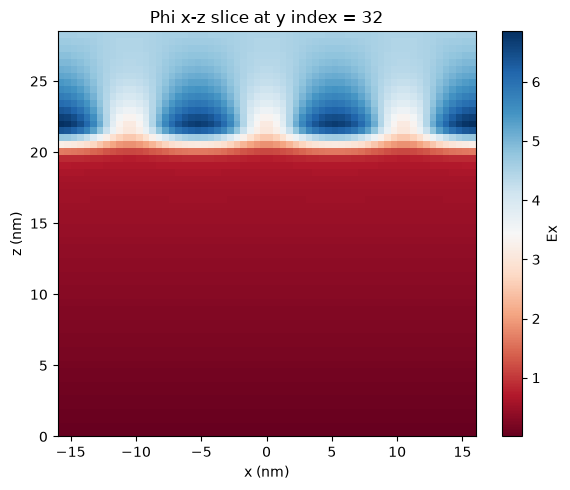

yt : [INFO     ] 2026-06-29 13:42:40,625 Parameters: current_time              = 1.019219999999142e-08


yt : [INFO     ] 2026-06-29 13:42:40,626 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:40,627 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:40,628 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


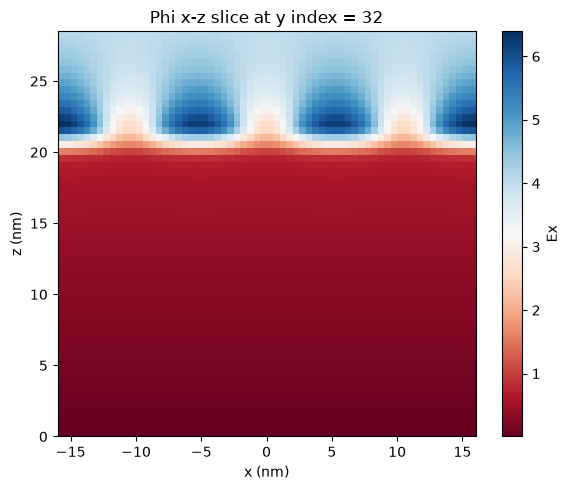

yt : [INFO     ] 2026-06-29 13:42:40,990 Parameters: current_time              = 1.0644399999989688e-08


yt : [INFO     ] 2026-06-29 13:42:40,991 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:40,992 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:40,993 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


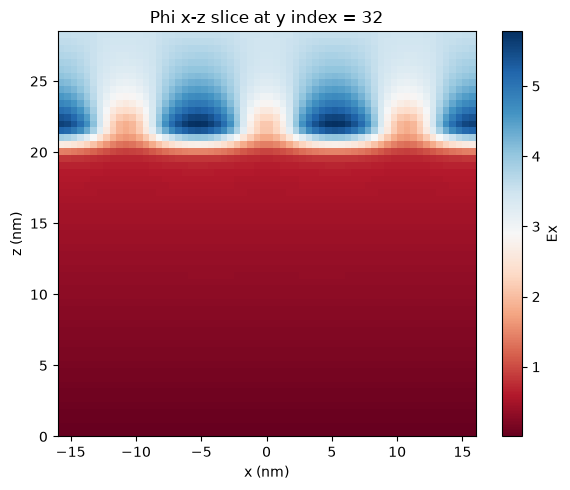

yt : [INFO     ] 2026-06-29 13:42:41,232 Parameters: current_time              = 1.123659999998742e-08


yt : [INFO     ] 2026-06-29 13:42:41,233 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:41,234 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:41,235 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


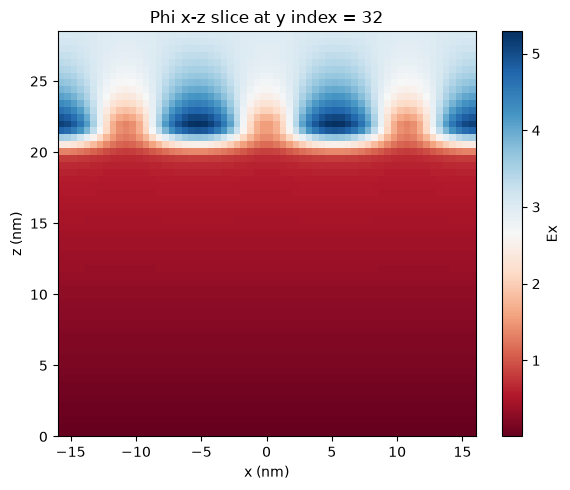

yt : [INFO     ] 2026-06-29 13:42:41,476 Parameters: current_time              = 1.1445999999986618e-08


yt : [INFO     ] 2026-06-29 13:42:41,477 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:41,478 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:41,479 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


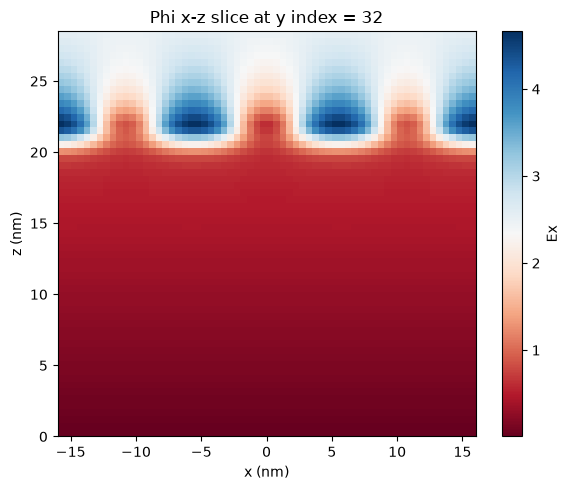

yt : [INFO     ] 2026-06-29 13:42:41,716 Parameters: current_time              = 1.154219999998625e-08


yt : [INFO     ] 2026-06-29 13:42:41,716 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:41,717 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:41,718 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


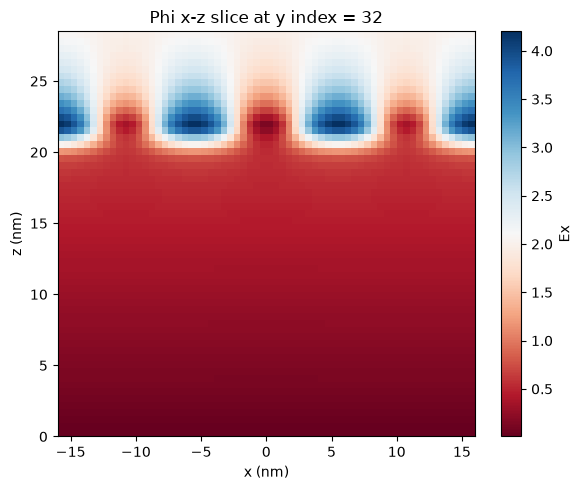

yt : [INFO     ] 2026-06-29 13:42:41,968 Parameters: current_time              = 1.2107199999984086e-08


yt : [INFO     ] 2026-06-29 13:42:41,969 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:41,970 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:41,971 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


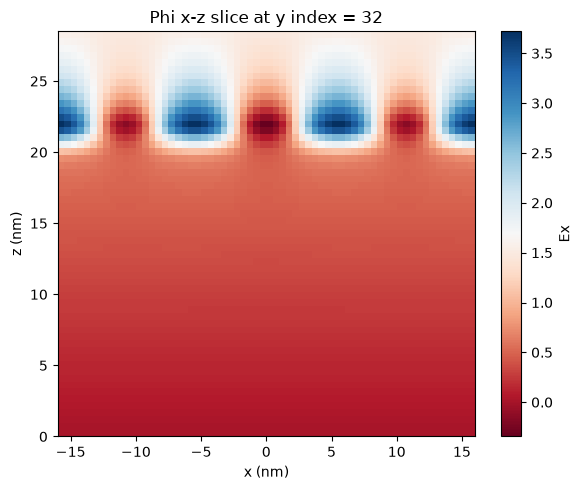

yt : [INFO     ] 2026-06-29 13:42:42,220 Parameters: current_time              = 1.2339799999983196e-08


yt : [INFO     ] 2026-06-29 13:42:42,220 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:42,221 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:42,222 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


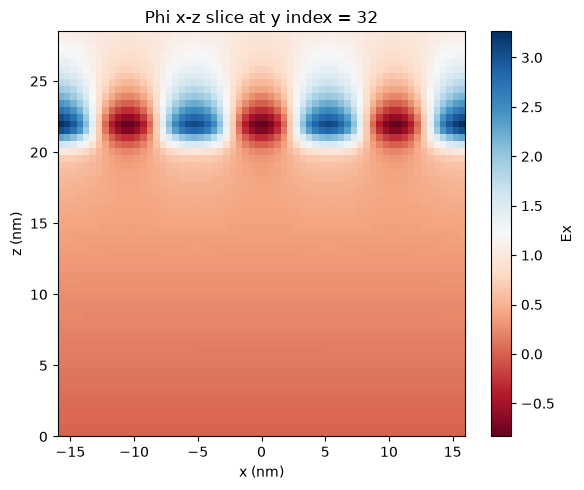

yt : [INFO     ] 2026-06-29 13:42:42,596 Parameters: current_time              = 1.267279999998192e-08


yt : [INFO     ] 2026-06-29 13:42:42,597 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:42,598 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:42,599 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


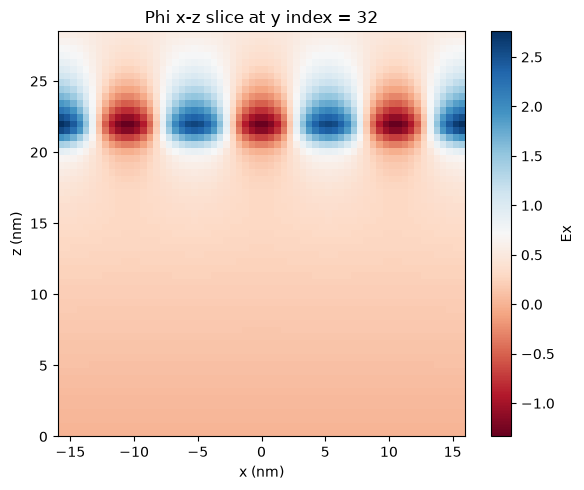

yt : [INFO     ] 2026-06-29 13:42:42,847 Parameters: current_time              = 1.2893599999981075e-08


yt : [INFO     ] 2026-06-29 13:42:42,848 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:42,849 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:42,850 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


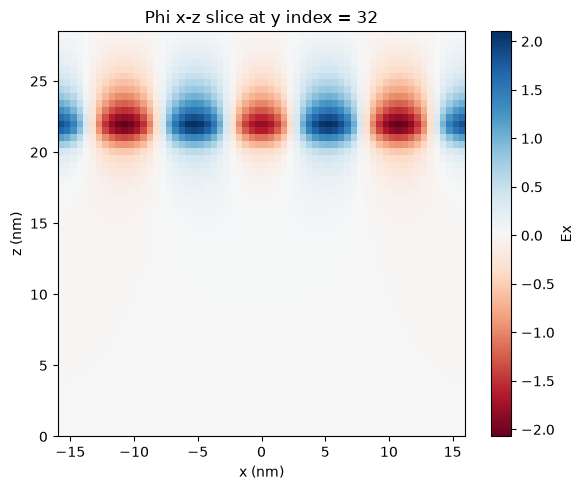

yt : [INFO     ] 2026-06-29 13:42:43,102 Parameters: current_time              = 1.3002599999980658e-08


yt : [INFO     ] 2026-06-29 13:42:43,103 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:43,104 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:43,105 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


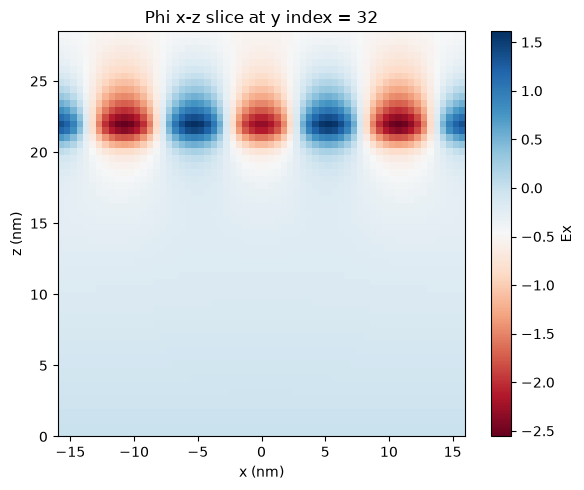

yt : [INFO     ] 2026-06-29 13:42:43,356 Parameters: current_time              = 1.3349799999979328e-08


yt : [INFO     ] 2026-06-29 13:42:43,357 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:43,358 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:43,359 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


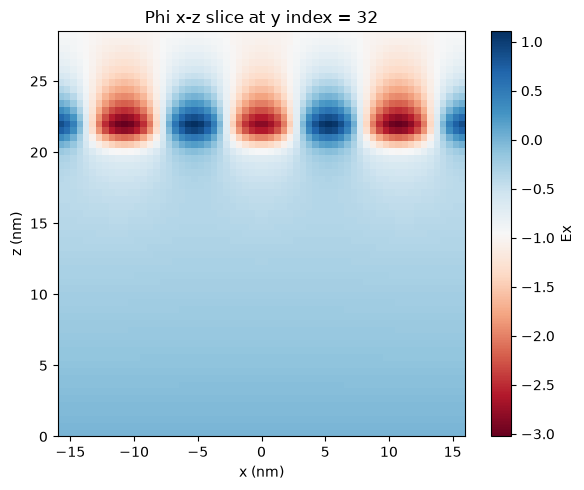

yt : [INFO     ] 2026-06-29 13:42:43,613 Parameters: current_time              = 1.3535599999978617e-08


yt : [INFO     ] 2026-06-29 13:42:43,614 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:43,615 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:43,616 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


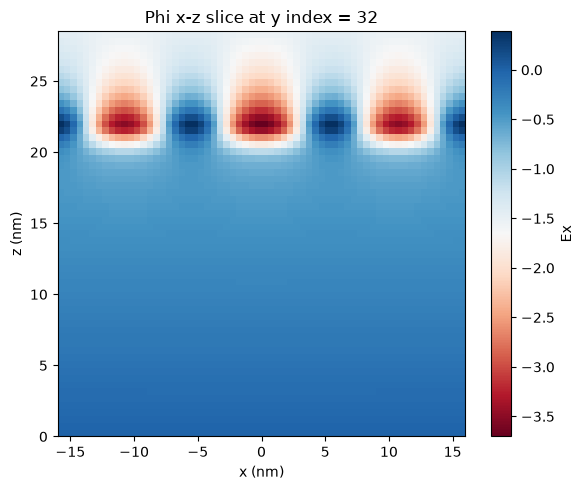

yt : [INFO     ] 2026-06-29 13:42:43,865 Parameters: current_time              = 1.3655999999978156e-08


yt : [INFO     ] 2026-06-29 13:42:43,865 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:43,866 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:43,867 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


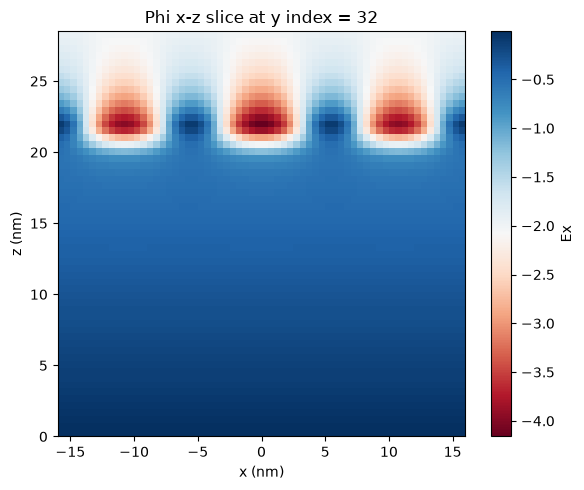

yt : [INFO     ] 2026-06-29 13:42:44,116 Parameters: current_time              = 1.419559999997609e-08


yt : [INFO     ] 2026-06-29 13:42:44,117 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:44,118 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:44,120 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


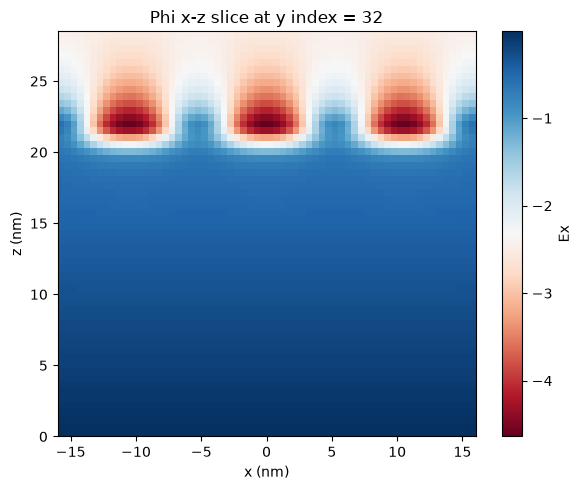

yt : [INFO     ] 2026-06-29 13:42:44,463 Parameters: current_time              = 1.4503199999974912e-08


yt : [INFO     ] 2026-06-29 13:42:44,464 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:44,465 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:44,466 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


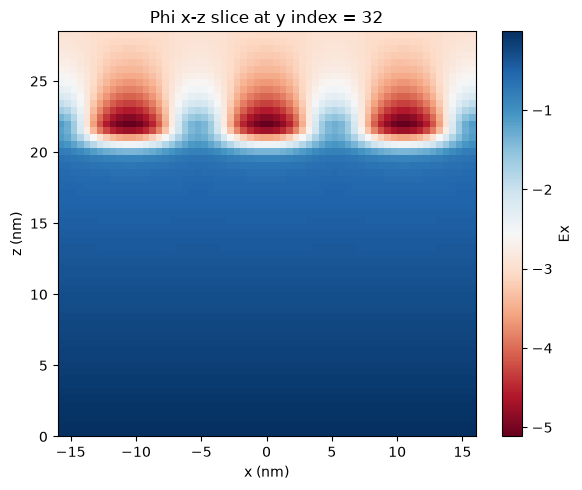

yt : [INFO     ] 2026-06-29 13:42:44,704 Parameters: current_time              = 1.4761399999973923e-08


yt : [INFO     ] 2026-06-29 13:42:44,705 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:44,706 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:44,706 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


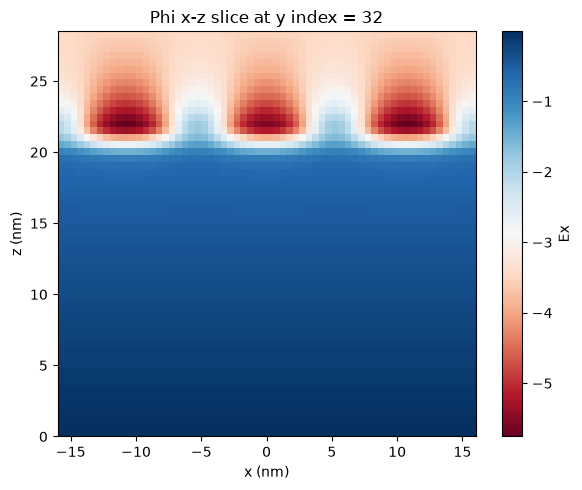

yt : [INFO     ] 2026-06-29 13:42:44,945 Parameters: current_time              = 1.546199999997588e-08


yt : [INFO     ] 2026-06-29 13:42:44,945 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:44,946 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:44,947 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


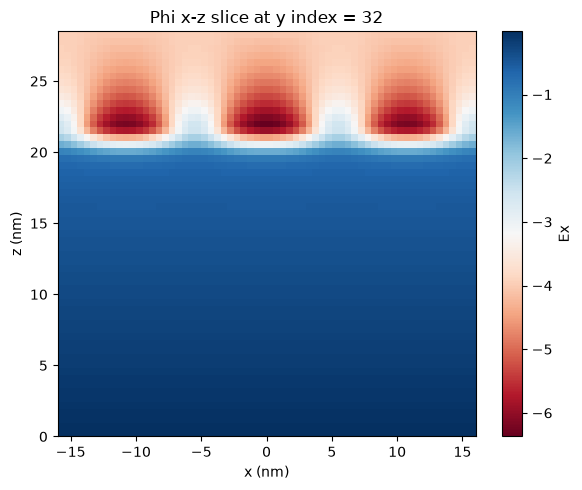

yt : [INFO     ] 2026-06-29 13:42:45,188 Parameters: current_time              = 1.5564999999976337e-08


yt : [INFO     ] 2026-06-29 13:42:45,189 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:45,190 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:45,191 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Phi_array shape = (64, 64, 59)


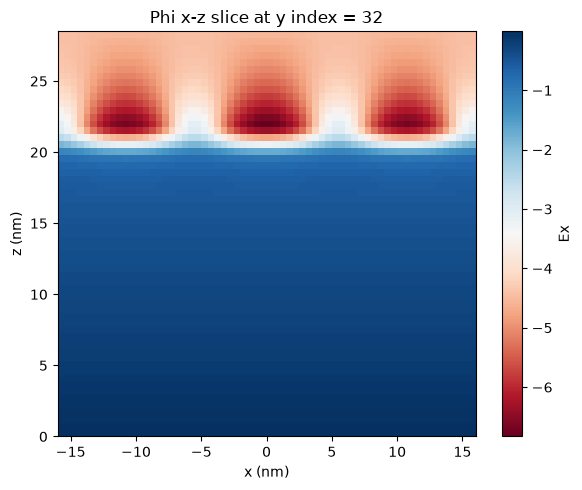

In [13]:
import yt
import numpy as np
import matplotlib.pyplot as plt
for i in range(len(plot_names)):
    plotfile = PLOT_DIR/plot_names[i] 
    field = ("boxlib", "Phi")

    ds = yt.load(plotfile)

    #g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
    Phi_array = read_full_field_from_grids(ds, field) # 讀取整個 domain 的 Phi 資料，會自動合併多個 grid

    print("Phi_array shape =", Phi_array.shape)

    Nx, Ny, Nz = Phi_array.shape #用index存資料

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    dims = np.array([Nx, Ny, Nz])

    dx = (hi - lo) / dims

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    y0 = Ny // 2
    slice2d = Phi_array[:, y0, :]

    plt.figure(figsize=(6, 5))
    im = plt.pcolormesh(
        x_nm,
        z_nm,
        slice2d.T,
        shading="auto",
        cmap="RdBu"
    )

    plt.colorbar(im, label="Ex")
    plt.xlabel("x (nm)")
    plt.ylabel("z (nm)")
    plt.title(f"Phi x-z slice at y index = {y0}")
    plt.tight_layout()
    plt.show()

yt : [INFO     ] 2026-06-29 13:42:45,445 Parameters: current_time              = 8.735999999999306e-10


yt : [INFO     ] 2026-06-29 13:42:45,446 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:45,447 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:45,447 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


E_array shape = (64, 64, 59)


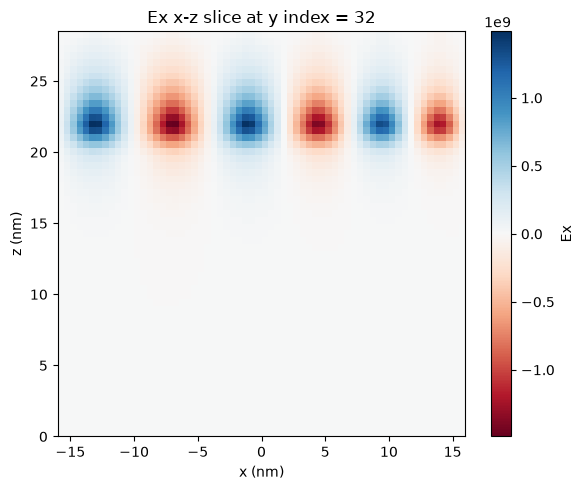

In [14]:
import yt
import numpy as np
import matplotlib.pyplot as plt

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_plt")  # 改成你 plotfile 所在的資料夾
plotfile = PLOT_DIR/plot_names[2] 
field = ("boxlib", "Ex")

ds = yt.load(plotfile)

#g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
E_array = read_full_field_from_grids(ds, field) # 讀取整個 domain 的 Ex 資料，會自動合併多個 grid

print("E_array shape =", E_array.shape)

Nx, Ny, Nz = E_array.shape #用index存資料

lo = ds.domain_left_edge.to_value()
hi = ds.domain_right_edge.to_value()
dims = np.array([Nx, Ny, Nz])

dx = (hi - lo) / dims

x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置
z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

y0 = Ny // 2
slice2d = E_array[:, y0, :]

plt.figure(figsize=(6, 5))
im = plt.pcolormesh(
    x_nm,
    z_nm,
    slice2d.T,
    shading="auto",
    cmap="RdBu"
)

plt.colorbar(im, label="Ex")
plt.xlabel("x (nm)")
plt.ylabel("z (nm)")
plt.title(f"Ex x-z slice at y index = {y0}")
plt.tight_layout()
plt.show()

## 2D Pz slice plot(all voltage in same graph)

yt : [INFO     ] 2026-06-29 13:42:45,718 Parameters: current_time              = 4.193600000000919e-09


yt : [INFO     ] 2026-06-29 13:42:45,719 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:45,720 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:45,721 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Plotfiles to draw:
  plt00020968
  plt00021574
  plt00023677
  plt00026857
  plt00028164
  plt00029726
  plt00031861
  plt00032470
  plt00034797
  plt00035286
  plt00035891
  plt00040599
  plt00041486
  plt00042133
  plt00044117
  plt00046245
  plt00047562
  plt00049790
  plt00050384
  plt00050961
  plt00053222
  plt00056183
  plt00057230
  plt00057711
  plt00060536
  plt00061699
  plt00063364
  plt00064468
  plt00065013
  plt00066749
  plt00067678
  plt00068280
  plt00070978
  plt00072516
  plt00073807
  plt00077310
  plt00077825
37 number of plotfiles will be drawn after filtering.


...

yt : [INFO     ] 2026-06-29 13:42:50,220 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:50,221 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:50,222 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Drawing 37 plots after filtering.


Saved figure: ./figs/Pz_FE_layer_stack.png


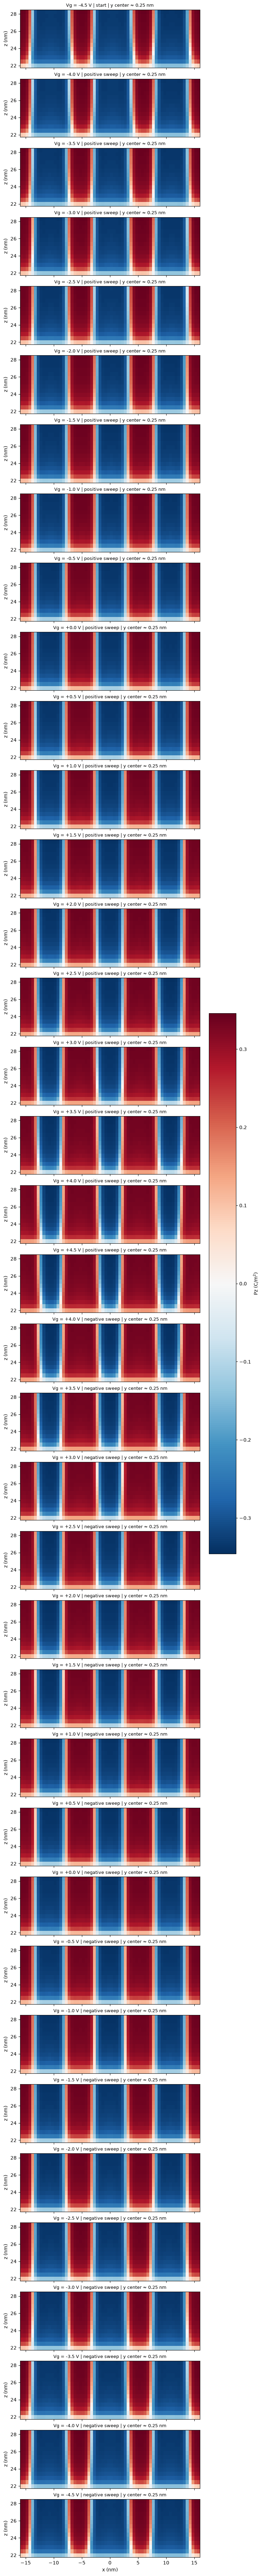

In [15]:
from pathlib import Path
import re

import yt
import numpy as np
import matplotlib.pyplot as plt


# ==========================
# User settings
# ==========================

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec")          # plotfile 所在資料夾
P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")

# ==========================
# Selection list (NEW)
# ==========================
# format: (voltage, direction)
# voltage 用 None 表示 wildcard
# direction 用 None 表示 wildcard
'''
SELECT_LIST = [
    
    (-0.5, "positive sweep"), 
    (-0.5, "negative sweep"),
   
]
'''
SELECT_LIST = None  # 不過濾，全部畫出來
USE_FE_X_RANGE = False

# y slice: None 表示取 y 方向正中間
Y_INDEX = None

# 若 plot_names 已經是你前面整理好的 steady-state plot list，就直接用
# plot_names = [...]
# 若沒有，就自動抓目前資料夾內所有 plt########
AUTO_FIND_PLOTS = False

# 跳過 initial plt00000000
SKIP_INITIAL = True

# 色階是否對稱於 0，畫 Pz 通常建議 True
SYMMETRIC_COLOR_SCALE = False

# 輸出圖片名稱
SAVE_FIG = True
OUT_FIG = "./figs/Pz_FE_layer_stack.png"


# ==========================
# Helper functions
# ==========================


def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v


def read_one_plot(plotfile, y_index=None):
    ds = yt.load(str(plotfile))
    #g = ds.index.grids[0]

    P = read_full_field_from_grids(ds, P_FIELD) # 讀取整個 domain 的 Pz 資料，會自動合併多個 grid
    P*=-1
    if PHI_FIELD in ds.field_list:
        Phi = read_full_field_from_grids(ds, PHI_FIELD) # 讀取整個 domain 的 Phi 資料，會自動合併多個 grid
    else:
        Phi = None

    Nx, Ny, Nz = P.shape

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    dx = (hi - lo) / np.array([Nx, Ny, Nz])

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
    y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    if y_index is None:
        y_index = Ny // 2

    # FE z range mask
    z_sel = (z_nm >= FE_Z_LO_NM) & (z_nm <= FE_Z_HI_NM)

    if USE_FE_X_RANGE:
        x_sel = (x_nm >= FE_X_LO_NM) & (x_nm <= FE_X_HI_NM)
    else:
        x_sel = np.ones_like(x_nm, dtype=bool)

    # P slice: shape after selection = (Nx_sel, Nz_sel)
    P_slice = P[np.ix_(x_sel, [y_index], z_sel)][:, 0, :]

    x_plot = x_nm[x_sel]
    z_plot = z_nm[z_sel]

    # 用最上層 cell 的 Phi 平均值當 top potential
    # 注意：這是 top cell center，不是真正 ghost boundary
    if Phi is not None:
        top_phi = Phi[:, :, -1]
        Vtop_mean = float(np.mean(top_phi))
        Vtop_min = float(np.min(top_phi))
        Vtop_max = float(np.max(top_phi))
    else:
        Vtop_mean = np.nan
        Vtop_min = np.nan
        Vtop_max = np.nan

    info = {
        "ds": ds,
        "P_slice": P_slice,
        "x_nm": x_plot,
        "z_nm": z_plot,
        "y_index": y_index,
        "y_nm": float(y_nm[y_index]),
        "Vtop_mean": Vtop_mean,
        "Vtop_min": Vtop_min,
        "Vtop_max": Vtop_max,
        "shape": P.shape,
    }

    return info



def match(rec, direction):# FILTER BY SELECT_LIST
    if not SELECT_LIST:
        return True
    V = rec["Vtop_mean"]

    for v_target, d_target in SELECT_LIST:

        ok_v = (v_target is None) or (
            np.isfinite(V) and np.isclose(V, v_target, atol=1e-1)
        )

        ok_d = (d_target is None) or (direction == d_target)

        if ok_v and ok_d:
            return True

    return False

# ==========================
# Main
# ==========================

if AUTO_FIND_PLOTS:
    plot_names_use = find_plot_names(PLOT_DIR)
else:
    plot_names_use = list(plot_names)

# sort by step if names are plt########
plot_names_use = sorted(plot_names_use, key=lambda n: get_step_from_name(n) if get_step_from_name(n) is not None else 10**99)

if SKIP_INITIAL:
    plot_names_use = [
        n for n in plot_names_use
        if get_step_from_name(n) != 0
    ]

#忽略第一段
plot_names_use = plot_names_use[9:]
    
print("Plotfiles to draw:")
for n in plot_names_use:
    print(" ", n)
print(len(plot_names_use), "number of plotfiles will be drawn after filtering.")

records = []
all_values = []

for name in plot_names_use:
    plotfile = PLOT_DIR / name
    info = read_one_plot(plotfile, y_index=Y_INDEX)

    step = get_step_from_name(name)

    records.append({
        "name": name,
        "step": step,
        **info,
    })

    all_values.append(info["P_slice"])

# shared color scale
all_concat = np.concatenate([v.ravel() for v in all_values])
if SYMMETRIC_COLOR_SCALE:
    vmax = np.nanmax(np.abs(all_concat))
    vmin = -vmax
else:
    vmin = np.nanmin(all_concat)
    vmax = np.nanmax(all_concat)

# determine sweep direction from Vtop sequence
Vseq = np.array([r["Vtop_mean"] for r in records], dtype=float)

directions = []
for idx, V in enumerate(Vseq):
    if idx == 0 or not np.isfinite(Vseq[idx-1]) or not np.isfinite(V):
        directions.append("start")
    else:
        dV = V - Vseq[idx-1]
        if dV > 1e-8:
            directions.append("positive sweep")
        elif dV < -1e-8:
            directions.append("negative sweep")
        else:
            directions.append("same V")

filtered_records = []
filtered_directions = []

for rec, d in zip(records, directions):
    if match(rec, d):
        filtered_records.append(rec)
        filtered_directions.append(d)

records = filtered_records
directions = filtered_directions

# figure size
n = len(records)
print(f"Drawing {n} plots after filtering.")
fig_height = max(2.0 * n, 4.0)
fig, axes = plt.subplots(
    nrows=n,
    ncols=1,
    figsize=(7.5, fig_height),
    sharex=True,
    constrained_layout=True
)


if n == 1:
    axes = [axes]

last_im = None

for ax, rec, sweep_dir in zip(axes, records, directions):
    P_slice = rec["P_slice"]
    x_nm = rec["x_nm"]
    z_nm = rec["z_nm"]

    last_im = ax.pcolormesh(
        x_nm,
        z_nm,
        P_slice.T,
        shading="auto",
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax
    )

    Vmean = rec["Vtop_mean"]
    Vmin = rec["Vtop_min"]
    Vmax = rec["Vtop_max"]

    if np.isfinite(Vmean):
        v_label = f"Vg = {Vmean:+.1f} V"
        # 若你想檢查 top x/y variation，也可以顯示 min/max
        # v_label += f" [{Vmin:+.3f}, {Vmax:+.3f}]"
    else:
        v_label = "Vtop unavailable"

    step_label = f"step={rec['step']}" if rec["step"] is not None else rec["name"]

    ax.set_ylabel("z (nm)")

    ax.set_title(
        f"{v_label} | {sweep_dir} | "
        f"y center ≈ {rec['y_nm']:.2f} nm",
        fontsize=9
    )

axes[-1].set_xlabel("x (nm)")
axes[-1].tick_params(axis='x', labelbottom=True)
'''
for ax in axes:
    ax.set_xlabel("x (nm)")
    ax.tick_params(axis='x', labelbottom=True)
'''
cbar = fig.colorbar(last_im, ax=axes, shrink=0.8)
cbar.set_label(r"Pz (C/m$^2$)")

if SAVE_FIG:
    fig.savefig(OUT_FIG, dpi=200)
    print(f"Saved figure: {OUT_FIG}")

plt.show()

## PV

### User Settings

In [16]:
from pathlib import Path
import re

import yt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ==========================
# User settings
# ==========================

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_1_plt")

P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")


# 如果 FE 是全幅 MFIS，通常不用限制 x/y
USE_FE_X_RANGE = False


USE_FE_Y_RANGE = False
# 若你已經有 steady-state plot_names，就用 AUTO_FIND_PLOTS=False
# plot_names = [...]
AUTO_FIND_PLOTS = True

# 如果沒有 plot_names，可以自動找所有 plt########
# 但建議最好只用 steady-state plotfiles
SKIP_INITIAL = True

OUT_CSV = "./figs/MFIS_PV_curve.csv"
OUT_FIG = "./figs/MFIS_PV_curve.png"


### Utils

In [17]:
# ==========================
# Helper functions
# ==========================

def get_step_from_name(name):
    m = re.fullmatch(r"plt(\d+)", str(name))
    return int(m.group(1)) if m else None


def find_plot_names(plot_dir):
    names = []
    for p in plot_dir.iterdir():
        if p.is_dir() and re.fullmatch(r"plt\d+", p.name):
            names.append(p.name)
    names.sort(key=lambda n: get_step_from_name(n))
    return names


def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v

def read_full_field_from_grids(ds, field):
    """
    Read a cell-centered AMReX field from all yt grids
    and stitch them into one full-domain numpy array.

    Return:
        full: numpy array with shape ds.domain_dimensions
    """
    dims = np.array(ds.domain_dimensions, dtype=int)
    full = np.empty(tuple(dims), dtype=float)

    domain_lo = ds.domain_left_edge.to_value()
    domain_hi = ds.domain_right_edge.to_value()
    dx = (domain_hi - domain_lo) / dims

    for grid in ds.index.grids:
        arr = to_numpy(grid[field])

        left = grid.LeftEdge.to_value()

        # grid start index in global domain
        start = np.rint((left - domain_lo) / dx).astype(int)

        nx, ny, nz = arr.shape
        i0, j0, k0 = start
        i1, j1, k1 = i0 + nx, j0 + ny, k0 + nz

        full[i0:i1, j0:j1, k0:k1] = arr

    return full

def read_pv_from_plot(plotfile):
    ds = yt.load(str(plotfile))
    Pz = read_full_field_from_grids(ds, P_FIELD)
    Phi = read_full_field_from_grids(ds, PHI_FIELD)

    Nx, Ny, Nz = Pz.shape
    print(f"Read Pz with shape {Pz.shape} from {plotfile}")

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    print(f"Domain: x [{lo[0]:.3e}, {hi[0]:.3e}] m, "
          f"y [{lo[1]:.3e}, {hi[1]:.3e}] m, "
          f"z [{lo[2]:.3e}, {hi[2]:.3e}] m")
    dx = (hi - lo) / np.array([Nx, Ny, Nz])

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
    y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    z_sel = (z_nm >= FE_Z_LO_NM) & (z_nm <= FE_Z_HI_NM)

    if USE_FE_X_RANGE:
        x_sel = (x_nm >= FE_X_LO_NM) & (x_nm <= FE_X_HI_NM)
    else:
        x_sel = np.ones_like(x_nm, dtype=bool)

    if USE_FE_Y_RANGE:
        y_sel = (y_nm >= FE_Y_LO_NM) & (y_nm <= FE_Y_HI_NM)
    else:
        y_sel = np.ones_like(y_nm, dtype=bool)

    Pz_FE = Pz[np.ix_(x_sel, y_sel, z_sel)]

    P_mean = float(np.mean(Pz_FE))
    P_min = float(np.min(Pz_FE))
    P_max = float(np.max(Pz_FE))
    P_std = float(np.std(Pz_FE))

    # 用最上層 cell 的 Phi 平均值估 top electrode potential
    # 注意：這是 top cell center，不是真正 ghost boundary
    top_phi = Phi[:, :, -1]
    Vg_mean = float(np.mean(top_phi))
    Vg_min = float(np.min(top_phi))
    Vg_max = float(np.max(top_phi))
    Vg_std = float(np.std(top_phi))

    return {
        "P_mean": P_mean,
        "P_min": P_min,
        "P_max": P_max,
        "P_std": P_std,
        "Vg_mean": Vg_mean,
        "Vg_min": Vg_min,
        "Vg_max": Vg_max,
        "Vg_std": Vg_std,
        "Nx": Nx,
        "Ny": Ny,
        "Nz": Nz,
        "num_FE_cells": int(Pz_FE.size),
    }



### Data Preparation

In [18]:



# ==========================
# Main
# ==========================

if AUTO_FIND_PLOTS:
    print(f"Finding plotfiles in {PLOT_DIR}...")
    plot_names_use = find_plot_names(PLOT_DIR)
else:
    plot_names_use = list(plot_names)

plot_names_use = sorted(
    plot_names_use,
    key=lambda n: get_step_from_name(n) if get_step_from_name(n) is not None else 10**99
)

if SKIP_INITIAL:
    plot_names_use = [
        n for n in plot_names_use
        if get_step_from_name(n) != 0
    ]
plot_names_use = plot_names_use[9:]  # skip first 9 plotfiles
rows = []

print(plot_names_use)

for name in plot_names_use:
    plotfile = PLOT_DIR / name
    step = get_step_from_name(name)

    info = read_pv_from_plot(plotfile)

    rows.append({
        "plotfile": name,
        "step": step,
        **info,
    })

    print(
        f"{name} | step={step} | "
        f"Vg={info['Vg_mean']:+.4f} V | "
        f"<Pz>_FE={info['P_mean']:+.6e}"
    )

df = pd.DataFrame(rows)
df.to_csv(OUT_CSV, index=False)
print(f"Saved CSV: {OUT_CSV}")


# ==========================
# Determine sweep direction
# ==========================

V = df["Vg_mean"].to_numpy()
P = df["P_mean"].to_numpy()


direction = np.zeros_like(V)

for i in range(1, len(V)):
    dV = V[i] - V[i - 1]
    if dV > 1e-8:
        direction[i] = 1   # positive sweep
    elif dV < -1e-8:
        direction[i] = -1  # negative sweep
    else:
        direction[i] = direction[i - 1]

#np.append(direction, direction[-1])  # 複製第一筆到最後

df["sweep_direction"] = direction
df.to_csv(OUT_CSV, index=False)




yt : [INFO     ] 2026-06-29 13:42:57,749 Parameters: current_time              = 4.193600000000919e-09


yt : [INFO     ] 2026-06-29 13:42:57,750 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:42:57,751 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:42:57,752 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


yt : [INFO     ] 2026-06-29 13:42:57,871 Parameters: current_time              = 4.314800000000956e-09


...

yt : [INFO     ] 2026-06-29 13:43:02,367 Parameters: current_time              = 1.5564999999976337e-08


yt : [INFO     ] 2026-06-29 13:43:02,368 Parameters: domain_dimensions         = [64 64 59]


yt : [INFO     ] 2026-06-29 13:43:02,369 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]


yt : [INFO     ] 2026-06-29 13:43:02,370 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Read Pz with shape (64, 64, 59) from plts/plt00077310
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00077310 | step=77310 | Vg=-4.0064 V | <Pz>_FE=+7.784730e-02
Read Pz with shape (64, 64, 59) from plts/plt00077825
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00077825 | step=77825 | Vg=-4.5057 V | <Pz>_FE=+8.497370e-02
Saved CSV: ./figs/MFIS_PV_curve.csv


### plot pv

In [19]:
print(len(P))

37


Saved figure: ./figs/MFIS_PV_curve.png


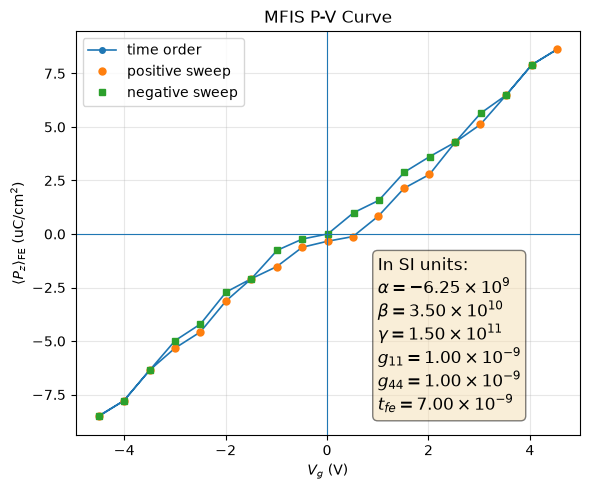

In [20]:
def sci_tex(x, sig=2):
    """Return LaTeX like 1.23\\times10^{-4} (no 'e')."""
    if x == 0:
        return r"0"
    exp = int(np.floor(np.log10(abs(x))))
    mant = x / (10 ** exp)
    return rf"{mant:.{sig}f}\times 10^{{{exp}}}"

# ==========================
# Plot PV curve
# ==========================

plt.figure(figsize=(6, 5))

textstr = '\n'.join((
    r'In SI units:',
    rf'$\alpha={sci_tex(ALPHA, sig=2)}$',
    rf'$\beta={sci_tex(BETA, sig=2)}$',
    rf'$\gamma={sci_tex(SMALL_GAMMA, sig=2)}$',
    rf'$g_{{11}}={sci_tex(G11, sig=2)}$',
    rf'$g_{{44}}={sci_tex(G44, sig=2)}$',
    rf'$t_{{fe}}={sci_tex((FE_Z_HI_NM-FE_Z_LO_NM)*1e-9, sig=2)}$',
))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(1, -1, textstr, fontsize=12,
        verticalalignment='top', bbox=props)

# time-order full loop
plt.plot(V, -P*100, "-o", markersize=4, linewidth=1.2, label="time order")
# paper data
#plt.plot(Vp, Pp, "-o", markersize=4, linewidth=1.2, label="paper")
# no f data
#plt.plot(Vnf, -Pnf*100, "-o", markersize=4, linewidth=1.2, label="before")
# optional: highlight positive / negative sweep
pos = df["sweep_direction"].to_numpy() >= 0
neg = df["sweep_direction"].to_numpy() < 0

if np.any(pos):
    plt.plot(V[pos], -P[pos]*100, "o", markersize=5, label="positive sweep")

if np.any(neg):
    plt.plot(V[neg], -P[neg]*100, "s", markersize=5, label="negative sweep")


plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel(r"$V_g$ (V)")
plt.ylabel(r"$\langle P_z \rangle_\mathrm{FE}$ (uC/cm$^2$)")
plt.title("MFIS P-V Curve")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(OUT_FIG, dpi=200)
print(f"Saved figure: {OUT_FIG}")

plt.show()

# update html

## utils

In [21]:
from pathlib import Path
from datetime import datetime
import re


def make_image_cell(img_path):
    if img_path is None or img_path == "":
        return "<td>No Image</td>"

    return f"""
<td>
<a href="{img_path}" target="_blank">
<img src="{img_path}">
</a>
</td>
"""


def update_dashboard(
    folder,
    params,
    tfe,
    start_time=None,
    end_time=None,
    elapsed_time=None,
    pv=None,
    pz=None,
    html_file="index.html",
):
    """
    folder : 資料夾名稱 (例如 MFIS001)

    params : dict
        {
            "alpha":...,
            "beta":...,
            ...
        }

    tfe : float

    pv,pz : 相對於 index.html 的圖片路徑
    """

    html_file = Path(html_file)

    with open(html_file, encoding="utf8") as f:
        html = f.read()

    # ---------- 防止重複 ----------
    
    folders = set(
        re.findall(
            r'<tr>\s*<td[^>]*>(.*?)</td>',
            html,
            re.DOTALL
        )
    )

    if folder in folders:
        print(f"{folder} already exists. Skip.")
        return

    # ---------- 更新時間 ----------
    now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    html = re.sub(
        r'(<span id="last_update">).*?(</span>)',
        rf"\g<1>{now}\g<2>",
        html,
        flags=re.S,
    )

    # ---------- 更新總數 ----------
    # 網頁java自動更新總數，這裡不需要

    
    # ---------- 新增一列 ----------
    row = f'<tr>\n<td>{folder}</td>'

    wanted = [
        "alpha",
        "beta",
        "gamma",
        "BigGamma",
        "g11",
        "g44",
        "FE_lo",
        "FE_hi",
    ]

    for p in wanted:
        if p == "FE_lo" or p == "FE_hi":
            continue
            
        value = params.get(p)

        if value is None:
            txt = ""

        elif isinstance(value, list):
            txt = " ".join(f"{v:.3e}" for v in value)

        else:
            txt = f"{value:.3e}"

        row += f'<td>{txt}</td>'

    row += f'<td>{tfe:.3e}</td>'
    row += f'<td>{start_time}</td>'
    row += f'<td>{end_time}</td>'
    row += f'<td>{elapsed_time}</td>'
    
    

    row += make_image_cell(pv)

    row += make_image_cell(pz)

    row += "\n</tr>\n"
    
    html = html.replace(
        "</tbody>",
        row + "</tbody>",
    )

    with open(html_file, "w", encoding="utf8") as f:
        f.write(html)

    print(f"{folder} added.")

## main

In [22]:
from pathlib import Path

folder = Path.cwd().name
cwd = Path.cwd()

root = cwd.parent

pv = (cwd / "figs" / "MFIS_PV_curve.png").relative_to(root).as_posix()

pz = (cwd / "figs" / "Pz_FE_layer_stack.png").relative_to(root).as_posix()

update_dashboard(
    folder=folder,
    params=params,
    tfe=T_FE,
    start_time=start_time,
    end_time=end_time,
    elapsed_time=elapsed_hms,
    pv=pv,
    pz=pz,
    html_file=root / "index.html",
)




MFIS_t_7_nomi_3 added.
